In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt                                                         


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer 

In [6]:
df = pd.read_csv(r"C:\Users\Dr.Sumedha\Downloads\train.csv",usecols =["GarageQual","FireplaceQu","SalePrice"])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [10]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Number of houses')

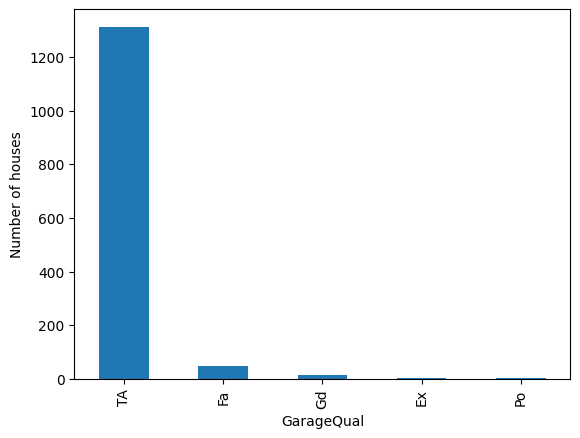

In [11]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel("GarageQual")
plt.ylabel("Number of houses")

<Axes: xlabel='GarageQual'>

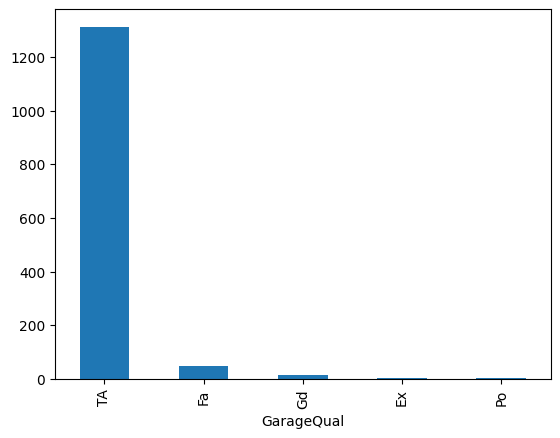

In [12]:
df["GarageQual"].value_counts().plot(kind="bar")

In [13]:
df["GarageQual"].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

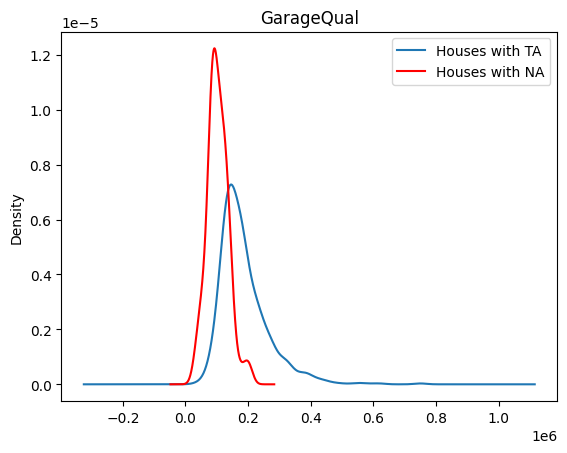

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df["GarageQual"]=="TA"]["SalePrice"].plot(kind="kde", ax=ax)
df[df["GarageQual"].isnull()]["SalePrice"].plot(kind="kde",ax=ax,color="red")

lines, labels = ax.get_legend_handles_labels()
labels=["Houses with TA","Houses with NA"]
ax.legend(lines, labels, loc="best")

plt.title("GarageQual")


In [15]:
temp = df[df["GarageQual"]=="TA"]["SalePrice"]

In [16]:
df["GarageQual"].fillna("TA",inplace=True)

<Axes: xlabel='GarageQual'>

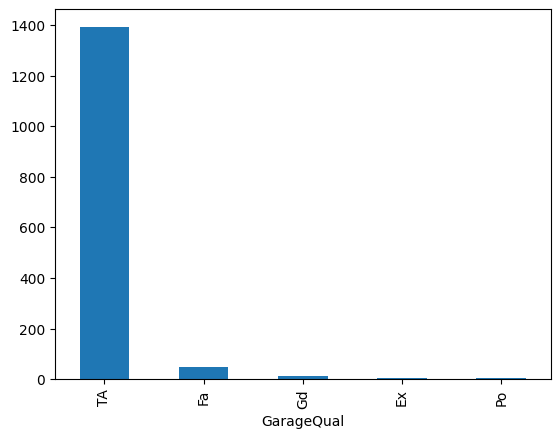

In [17]:
df["GarageQual"].value_counts().plot(kind="bar")

Text(0.5, 1.0, 'GarageQual')

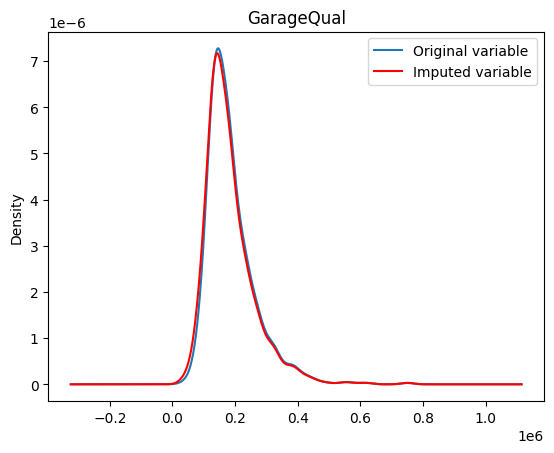

In [18]:
fig = plt.figure()
ax = fig.add_subplot()

temp.plot(kind="kde", ax = ax)

# distribution of the variable after imputation 
df[df["GarageQual"] == "TA"]["SalePrice"].plot(kind="kde", ax=ax,color = "red")

lines, labels = ax.get_legend_handles_labels()
labels = ["Original variable", "Imputed variable"]
ax.legend(lines,labels,loc="best")

# add title
plt.title("GarageQual")

<Axes: xlabel='FireplaceQu'>

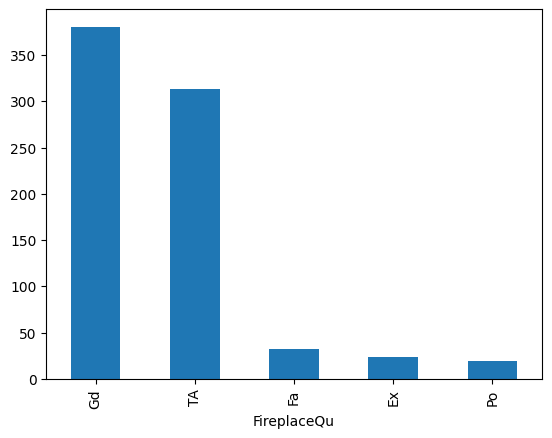

In [19]:
df["FireplaceQu"].value_counts().plot(kind="bar")

In [20]:
df["FireplaceQu"].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

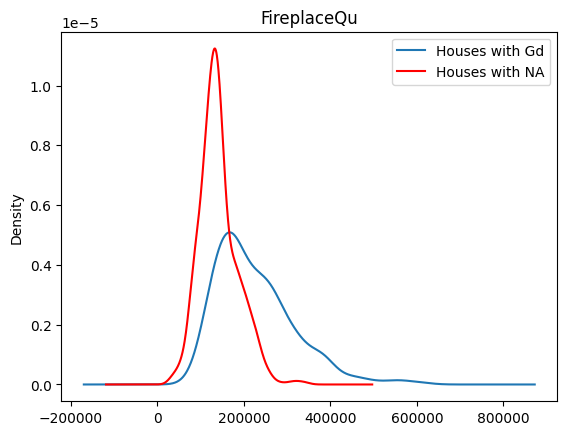

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df["FireplaceQu"] == "Gd"]["SalePrice"].plot(kind="kde", ax=ax)
df[df["FireplaceQu"].isnull()]["SalePrice"].plot(kind="kde", ax=ax, color="red")

lines, labels = ax.get_legend_handles_labels()
labels = ["Houses with Gd", "Houses with NA"]
ax.legend(lines, labels, loc="best")

plt.title("FireplaceQu")


In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=["SalePrice"]),df["SalePrice"],test_size=0.2)


In [28]:
from sklearn.impute import SimpleImputer

In [29]:
imputer = SimpleImputer(strategy="most_frequent")

In [ ]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)   # It is applying the imputer (filling missing values) on X_train ,And storing the result in X_test

C:\Users\Dr.Sumedha\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [32]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

In [35]:
df["GarageQual"].fillna("Missing",inplace=True)

Text(0, 0.5, 'Number of houses')

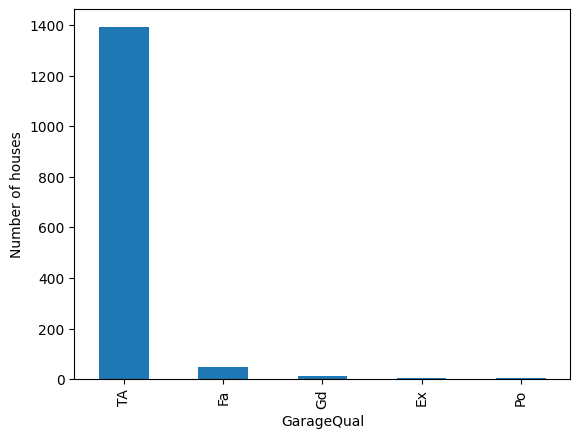

In [ ]:
df["GarageQual"].fillna("Missing",inplace=True)
df["GarageQual"].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel("GarageQual")
plt.ylabel("Number of houses")

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=["SalePrice"]),df["SalePrice"],test_size=0.2)

In [40]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy="constant",fill_value="Missing")


In [42]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

In [43]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)